### Name: Jivan Sawant
### Roll No : TEBD23277
### Practical no : 5

1. Implement logistic regression using Python/R to perform classification on Social_Network_Ads.csv
dataset.
2. Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall on the given
dataset.

Logistic Regression is a classification algorithm used to predict YES/NO (0 or 1).

In [2]:

# import necessary libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

In [3]:
# Load the dataset
df = pd.read_csv("5Social_Network_Ads.csv")

In [4]:
# Display basic information about the dataset
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)

Shape: (400, 5)

Columns:
 Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='str')

Data Types:
 User ID            int64
Gender               str
Age                int64
EstimatedSalary    int64
Purchased          int64
dtype: object


In [22]:
# Add missing values into the dataset
numeric_cols = ["Age", "EstimatedSalary"] # select numeric columns

for col in numeric_cols:
    df.loc[df.sample(frac=0.05, random_state=42).index, col] = np.nan

print("\nMissing Values After Injection:\n", df.isnull().sum())


Missing Values After Injection:
 User ID             0
Gender              0
Age                20
EstimatedSalary    20
Purchased           0
dtype: int64


In [6]:
# Summary statistics
print("\nStatistical Summary:\n", df.describe())


Statistical Summary:
              User ID         Age  EstimatedSalary   Purchased
count     400.000000  380.000000       380.000000  400.000000
mean   100199.500000   39.068421     84339.239474    0.627500
std       115.614301   11.689499     40005.794339    0.484076
min    100000.000000   18.000000     15126.000000    0.000000
25%    100099.750000   29.000000     52524.250000    0.000000
50%    100199.500000   40.000000     85435.000000    1.000000
75%    100299.250000   49.000000    119546.000000    1.000000
max    100399.000000   59.000000    149869.000000    1.000000


In [7]:
# count gender and target values to understand distribution
print("\nGender Distribution:\n", df["Gender"].value_counts())
print("\nTarget Distribution:\n", df["Purchased"].value_counts())



Gender Distribution:
 Gender
Female    201
Male      199
Name: count, dtype: int64

Target Distribution:
 Purchased
1    251
0    149
Name: count, dtype: int64


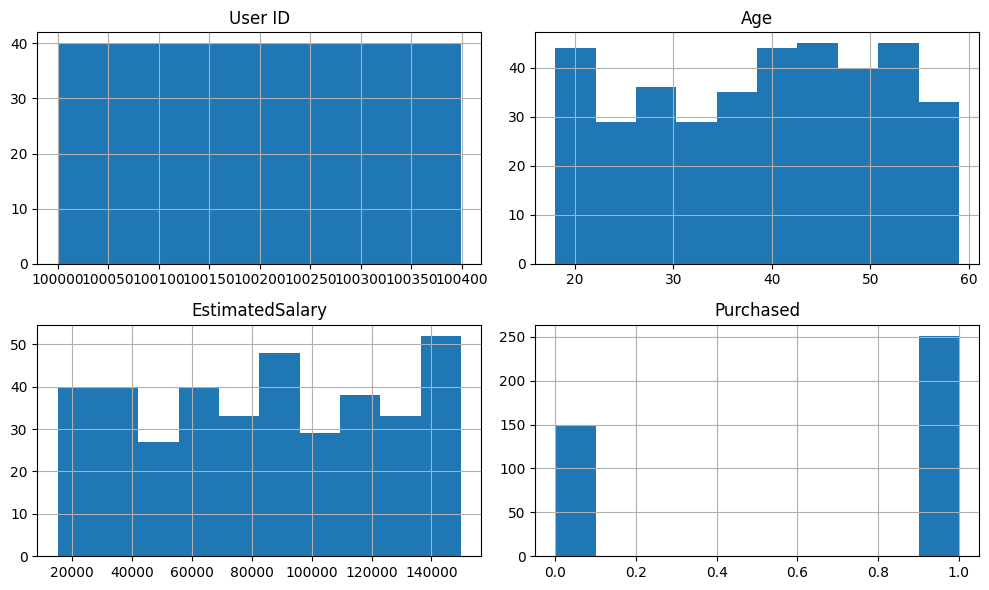

In [ ]:
# Histograms for all columns 
df.hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

# Age value mostly between 20 and 50
#Salary ranges from low to high (15k–150k)
#Dataset is binary, showing whether a user purchased or not.

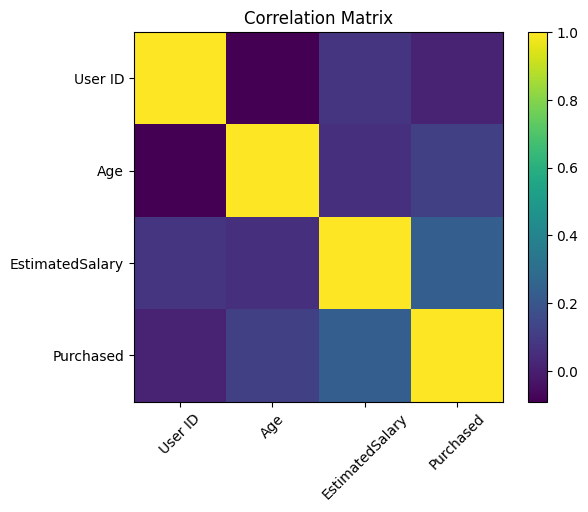

In [ ]:
# Correlation matrix
corr = df.corr(numeric_only=True)

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
# Set x and y ticks to column names
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()
#Bright color → strong relation
#Dark color → weak relation

Number of outliers detected: 0


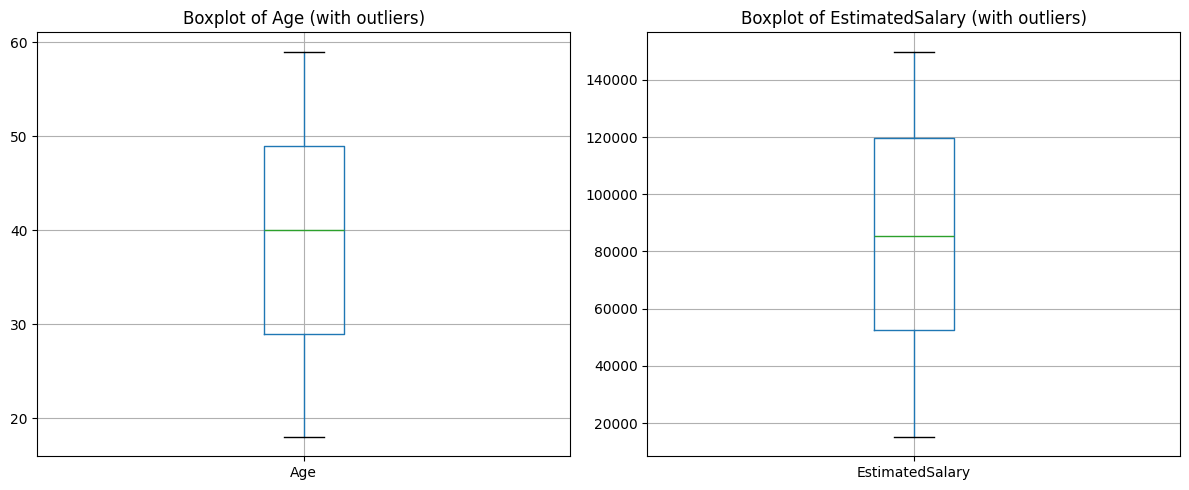

Original dataset shape: (400, 5)
Cleaned dataset shape: (400, 5)
Removed 0 outliers


In [23]:
# Outlier Detection and Removal using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # return index of outliers
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)].index
    return outliers

# Detect outliers in numeric columns
outlier_indices = set()
for col in ['Age', 'EstimatedSalary']:
    outliers = detect_outliers_iqr(df, col)
    outlier_indices.update(outliers)

print(f"Number of outliers detected: {len(outlier_indices)}")

# Visualize outliers with boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# age boxplot  
df.boxplot(column='Age', ax=axes[0])
axes[0].set_title('Boxplot of Age (with outliers)')
# salary boxplot
df.boxplot(column='EstimatedSalary', ax=axes[1])
axes[1].set_title('Boxplot of EstimatedSalary (with outliers)')

plt.tight_layout()
plt.show()

# Remove outliers
df_clean = df.drop(outlier_indices)
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Removed {len(outlier_indices)} outliers")

# Update dataframe
df = df_clean

In [14]:
# Define features and target
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

In [ ]:
# to fill the missing value 
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

X = pd.DataFrame(X, columns=['Age', 'EstimatedSalary'])
print(X.head())

    Age  EstimatedSalary
0  41.0         127816.0
1  28.0         143778.0
2  25.0          77292.0
3  53.0          38833.0
4  55.0          35309.0


In [27]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [ ]:
#Feature Scaling it is used to convert the value into similar range
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nPreprocessing Completed Successfully!")


Preprocessing Completed Successfully!


In [18]:
# Train a logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [29]:
# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Extract values
TN, FP, FN, TP = cm.ravel()

print("\nTP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

# Metrics

# Accuracy = (TP + TN) / (TP + TN + FP + FN)
accuracy = accuracy_score(y_test, y_pred)

# Precision = TP / (TP + FP)
precision = precision_score(y_test, y_pred)

# Recall = TP / (TP + FN)
recall = recall_score(y_test, y_pred)

# Error Rate = 1 - Accuracy = (FP + FN) / Total
error_rate = 1 - accuracy

print("\nAccuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)


Confusion Matrix:
 [[ 9 26]
 [14 51]]

TP: 51
TN: 9
FP: 26
FN: 14

Accuracy: 0.6
Error Rate: 0.4
Precision: 0.6623376623376623
Recall: 0.7846153846153846


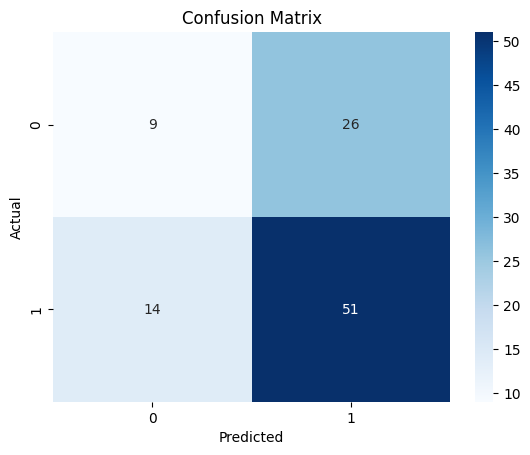

In [ ]:
# Visualize Confusion Matrix
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# TP = 51 → correctly predicted purchased
# TN = 9 → correctly predicted not purchased

# FP = 26 → predicted purchase but actually not
# FN = 14 → predicted not purchase but actually yes